# Week 12 — Future Work 5 (FW5): Hallucination-Rate Metric (CHAIR)

**Dissertation:** Advance Multimodel Generative Artificial Intelligence — Controllable Image Captioning with Large Vision-Language Models
**Author:** Avinash Sahu  |  **Supervisor:** Varun Ojha

**Goal (interim report, FW5):** add a **hallucination-rate metric** that counts objects a caption
*describes but that are absent from the image* — a complementary, safety-oriented accuracy measure
alongside BLEU-4 and CLIP.

**Method — CHAIR (Rohrbach et al., 2018, *Object Hallucination in Image Captioning*):**
using COCO's ground-truth object labels for each image, we detect which of the 80 COCO object
categories a caption mentions, then flag any mentioned object **not** present in the image as a
hallucination. We report the two standard CHAIR scores:
- **CHAIRs** (sentence level): fraction of captions containing at least one hallucinated object.
- **CHAIRi** (instance level): fraction of all mentioned objects that are hallucinated.

Lower is better for both. This runs over the captions you have **already generated** in Weeks 3–8
(and FW2 / FW4), so there is **no model inference and no GPU needed** — it is purely a new metric
over existing `results/*.csv`. It reuses your Week 1–8 paths and the COCO labels already on Drive.


In [ ]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [ ]:
# ── CELL 2 — (No heavy installs needed — pure text analysis) ─────────────
# Only standard libs + pandas, already present in Colab.
print('No GPU required for FW5. Proceed.')


No GPU required for FW5. Proceed.


In [ ]:
# ── CELL 3 — Paths and config ─────────────────────────────────────────────
import os, glob
BASE           = '/content/drive/MyDrive/dissertation_final'
INSTANCES_FILE = f'{BASE}/data/coco/annotations/instances_val2017.json'
RESULTS_DIR    = f'{BASE}/results'

# CSVs to score: any per-image result file with 'image_id' + 'generated' columns.
# Aggregate tables and video (MSR-VTT) results are skipped automatically.
SKIP_SUBSTR = ('FINAL_', 'results_table', 'fw3', 'comparison', 'interpolation',
               'attribute_steering', 'hallucination_detail', 'sanity')

print('instances_val2017.json present:', os.path.exists(INSTANCES_FILE))
print('results dir present           :', os.path.isdir(RESULTS_DIR))


instances_val2017.json present: True
results dir present           : True


In [ ]:
# -- CELL 4 -- Imports + BLEU helper -------------------------------------
import json, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def _txt(x):
    return ('' if (x is None or isinstance(x, float)) else str(x)).lower().split()

def corpus_bleu4(generated, references):
    s = SmoothingFunction().method1
    hyps = [_txt(g) for g in generated]
    refs = [[_txt(r) for r in rs] for rs in references]
    return round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4)

print('Imports done.')

Imports done.


In [ ]:
# ── CELL 5 — Ground-truth objects per image (COCO instances) ─────────────
with open(INSTANCES_FILE) as f:
    inst = json.load(f)
catid_to_name = {c['id']: c['name'] for c in inst['categories']}     # 80 COCO classes
gt_by_img = {}
for a in inst['annotations']:
    gt_by_img.setdefault(a['image_id'], set()).add(catid_to_name[a['category_id']])
print(f'COCO categories: {len(catid_to_name)} | images with GT objects: {len(gt_by_img)}')


COCO categories: 80 | images with GT objects: 4952


In [ ]:
# ── CELL 6 — COCO category synonym map (CHAIR-style) ─────────────────────
# Maps each of the 80 categories to words/phrases that count as a mention.
# Approximate (the original CHAIR uses a curated list); extend EXTRA for precision.
COCO80 = list(catid_to_name.values())

EXTRA = {
 'person': ['people','man','woman','men','women','child','children','boy','girl',
            'guy','lady','human','kid','kids','player','players','crowd','pedestrian'],
 'bicycle': ['bike','bikes','bicycles','cyclist'],
 'car': ['cars','automobile','automobiles','vehicle','vehicles','sedan','taxi'],
 'motorcycle': ['motorbike','motorbikes','motorcycles','scooter'],
 'airplane': ['plane','planes','aircraft','jet','airplanes'],
 'bus': ['buses','coach'],
 'truck': ['trucks','lorry'],
 'tv': ['television','televisions','monitor','screen'],
 'couch': ['sofa','sofas','couches'],
 'cell phone': ['cellphone','phone','phones','smartphone','mobile'],
 'airplane ': [],
 'dining table': ['table','tables','dining table'],
 'potted plant': ['plant','plants','potted plant'],
 'tv ': [],
 'sports ball': ['ball','balls','sports ball'],
 'wine glass': ['wine glass','wineglass'],
 'hot dog': ['hotdog','hot dog'],
 'donut': ['doughnut','donuts','doughnuts'],
 'sandwich': ['sandwiches'],
 'aeroplane': [],
}

def syns_for(cat):
    s = {cat, cat + 's'}                       # name + naive plural
    s |= set(EXTRA.get(cat, []))
    return {w for w in s if w}

SYN = {cat: syns_for(cat) for cat in COCO80}

def mentioned_categories(caption):
    """Return the set of COCO categories a caption mentions."""
    if caption is None or isinstance(caption, float):
        return set()
    text = str(caption).lower()
    words = set(re.findall(r"[a-z]+", text))
    found = set()
    for cat, words_set in SYN.items():
        for w in words_set:
            if ' ' in w:                       # multi-word category -> substring
                if w in text: found.add(cat); break
            else:                              # single word -> token match
                if w in words: found.add(cat); break
    return found

# sanity check
print(mentioned_categories('A man riding a bike next to a dog and a parked car.'))


{'person', 'bicycle', 'dog', 'car'}


In [ ]:
# ── CELL 7 — CHAIR computation for one set of captions ───────────────────
def chair_for_df(df):
    """df needs columns image_id + generated. Returns CHAIRs, CHAIRi, averages."""
    n_sent = 0; sent_with_halluc = 0
    total_mentions = 0; total_halluc = 0; gt_sizes = []
    per_rows = []
    for _, r in df.iterrows():
        img_id = int(r['image_id'])
        if img_id not in gt_by_img:            # not a COCO image -> skip
            continue
        gt = gt_by_img[img_id]
        mentioned = mentioned_categories(r['generated'])
        halluc = mentioned - gt
        n_sent += 1
        total_mentions += len(mentioned)
        total_halluc += len(halluc)
        gt_sizes.append(len(gt))
        if halluc: sent_with_halluc += 1
        per_rows.append({'image_id': img_id, 'generated': r['generated'],
                         'mentioned': ', '.join(sorted(mentioned)),
                         'hallucinated': ', '.join(sorted(halluc)),
                         'n_hallucinated': len(halluc)})
    if n_sent == 0:
        return None
    return {
        'N': n_sent,
        'CHAIRs (%)': round(100 * sent_with_halluc / n_sent, 2),
        'CHAIRi (%)': round(100 * total_halluc / total_mentions, 2) if total_mentions else 0.0,
        'avg objects mentioned': round(total_mentions / n_sent, 2),
        'avg GT objects': round(float(np.mean(gt_sizes)), 2),
    }, pd.DataFrame(per_rows)

print('CHAIR functions ready.')


CHAIR functions ready.


In [ ]:
# ── CELL 8 — Auto-discover per-image caption CSVs and score each ─────────
all_csvs = sorted(glob.glob(f'{RESULTS_DIR}/*.csv'))
rows = []
for path in all_csvs:
    name = os.path.basename(path)
    if any(sub in name for sub in SKIP_SUBSTR):
        continue
    try:
        df = pd.read_csv(path)
    except Exception:
        continue
    if not {'image_id', 'generated'}.issubset(df.columns):
        continue
    res = chair_for_df(df)
    if res is None:
        continue
    summary, per = res
    technique = name.replace('.csv', '')
    # accuracy metrics straight from THIS file's own columns (not a merge)
    b4 = np.nan
    if 'references' in df.columns:
        refs = [str(r).split(' | ') for r in df['references']]
        b4 = corpus_bleu4(df['generated'].tolist(), refs)
    cl = round(df['clip_score'].mean(), 4) if 'clip_score' in df.columns else np.nan
    summary = {'Technique': technique, **summary, 'BLEU-4': b4, 'CLIP score (mean)': cl}
    rows.append(summary)
    # save per-image hallucination detail for the dissertation appendix
    per.to_csv(f'{RESULTS_DIR}/hallucination_detail_{technique}.csv', index=False)
    print(f'scored {technique:40s} CHAIRs={summary["CHAIRs (%)"]:5}%  CHAIRi={summary["CHAIRi (%)"]:5}%  N={summary["N"]}')

if not rows:
    print('\nNo per-image caption CSVs with COCO image_ids found in results/.')
else:
    print(f'\nScored {len(rows)} caption sets.')


scored week11_fw4_blip2_action_focus            CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_attribute_rich          CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_baseline                CHAIRs=  8.0%  CHAIRi= 5.97%  N=100
scored week11_fw4_blip2_expert_coco             CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_expert_domain           CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_expert_vision           CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_object_focus            CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_style_formal            CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week11_fw4_blip2_style_simple            CHAIRs=  0.0%  CHAIRi=  0.0%  N=100
scored week3_baseline                           CHAIRs= 22.0%  CHAIRi=14.69%  N=100
scored week4_all_prompts                        CHAIRs=24.11%  CHAIRi=14.11%  N=900
scored week4_expert_expert_coco                 CHAIRs= 20.0%  CHAIRi=10.55%

In [ ]:
# ── CELL 9 — Aggregate FW5 table (+ merge BLEU/CLIP where available) ─────
fw5 = pd.DataFrame(rows).sort_values('CHAIRs (%)').reset_index(drop=True)

# BLEU-4 and CLIP are read directly from each file's own columns in Cell 8,
# so every technique has values (no fragile name-based merge).
fw5.to_csv(f'{RESULTS_DIR}/FINAL_results_fw5_hallucination.csv', index=False)
print('Saved: FINAL_results_fw5_hallucination.csv\n')
print('='*90)
print('FW5 — Hallucination rate (CHAIR). Lower = fewer described-but-absent objects.')
print('='*90)
print(fw5.to_string(index=False))


Saved: FINAL_results_fw5_hallucination.csv

FW5 — Hallucination rate (CHAIR). Lower = fewer described-but-absent objects.
                      Technique   N  CHAIRs (%)  CHAIRi (%)  avg objects mentioned  avg GT objects  BLEU-4  CLIP score (mean)
  week11_fw4_blip2_action_focus 100        0.00        0.00                   0.00             3.1  0.0000             0.1939
week11_fw4_blip2_attribute_rich 100        0.00        0.00                   0.00             3.1  0.0000             0.1939
   week11_fw4_blip2_expert_coco 100        0.00        0.00                   0.00             3.1  0.0000             0.1939
 week11_fw4_blip2_expert_domain 100        0.00        0.00                   0.00             3.1  0.0000             0.1939
  week11_fw4_blip2_object_focus 100        0.00        0.00                   0.00             3.1  0.0000             0.1939
 week11_fw4_blip2_expert_vision 100        0.00        0.00                   0.00             3.1  0.0000             0.1

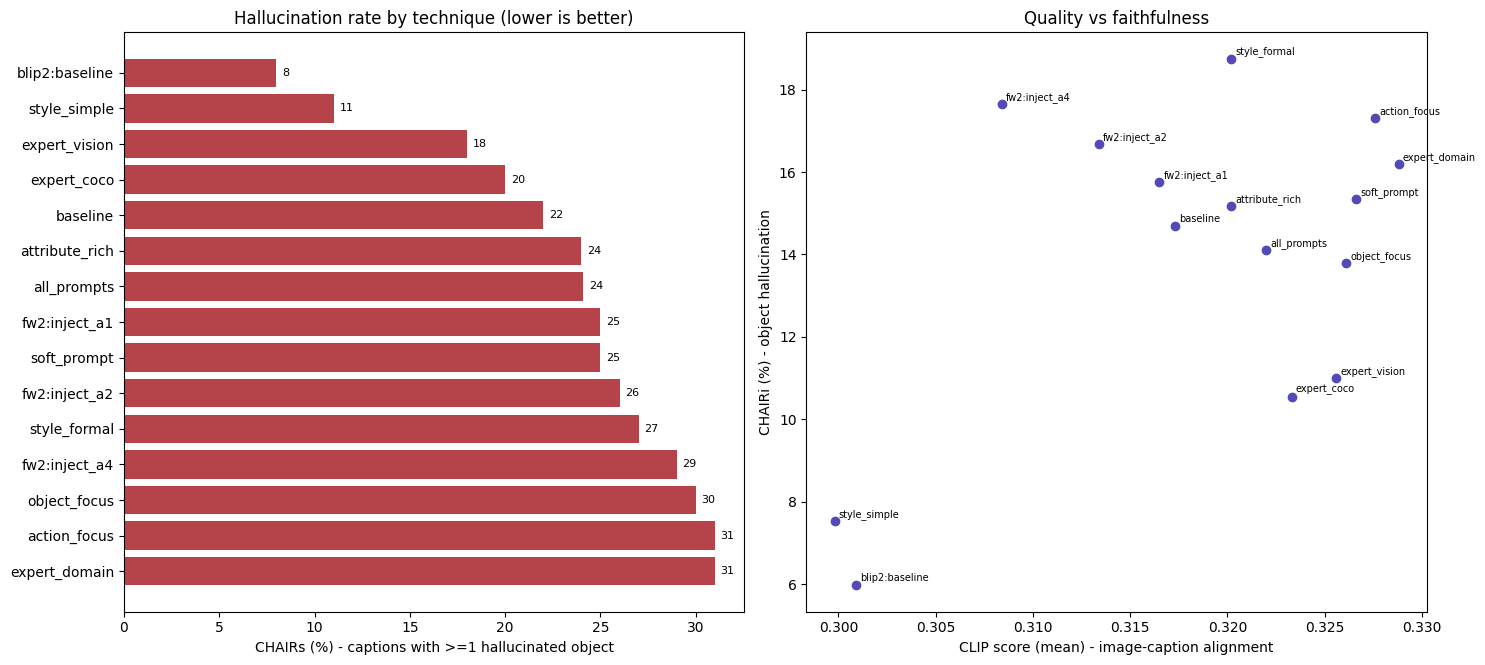

Saved figure: /content/drive/MyDrive/dissertation_final/results/week12_fw5_hallucination.png

Note: 9 technique(s) excluded from the plot - empty/degenerate captions
(0 objects mentioned, so CHAIR is not meaningful for them):
   - blip2:action_focus
   - blip2:attribute_rich
   - blip2:expert_coco
   - blip2:expert_domain
   - blip2:object_focus
   - blip2:expert_vision
   - blip2:style_formal
   - blip2:style_simple
   - lora

FW5 complete.


In [ ]:
# -- CELL 10 -- Plots (clean): hallucination by technique + quality vs faithfulness --
def short(t):
    return (t.replace('week11_fw4_blip2_', 'blip2:').replace('week9_fw2_', 'fw2:')
             .replace('week4_hard_', '').replace('week4_expert_', '')
             .replace('week4_', '').replace('week7_lora_eval', 'lora')
             .replace('week3_', ''))

# Keep only techniques whose captions actually mention objects (exclude empty/degenerate).
real  = fw5[fw5['avg objects mentioned'] > 0].copy()
empty = fw5[fw5['avg objects mentioned'] == 0]['Technique'].tolist()
real['label'] = real['Technique'].map(short)
real = real.sort_values('CHAIRs (%)').reset_index(drop=True)

h = max(4.0, 0.45 * len(real))
fig, ax = plt.subplots(1, 2, figsize=(15, h))

# (a) CHAIRs by technique
ax[0].barh(real['label'], real['CHAIRs (%)'], color='#B7434A')
ax[0].set_xlabel('CHAIRs (%) - captions with >=1 hallucinated object')
ax[0].set_title('Hallucination rate by technique (lower is better)')
ax[0].invert_yaxis()
for i, v in enumerate(real['CHAIRs (%)']):
    ax[0].text(v + 0.3, i, f'{v:.0f}', va='center', fontsize=8)

# (b) CLIP (quality) vs CHAIRi (hallucination) - top-left is best
sub = real.dropna(subset=['CLIP score (mean)'])
ax[1].scatter(sub['CLIP score (mean)'], sub['CHAIRi (%)'], color='#534AB7')
for _, r in sub.iterrows():
    ax[1].annotate(r['label'], (r['CLIP score (mean)'], r['CHAIRi (%)']),
                   fontsize=7, xytext=(3, 3), textcoords='offset points')
ax[1].set_xlabel('CLIP score (mean) - image-caption alignment')
ax[1].set_ylabel('CHAIRi (%) - object hallucination')
ax[1].set_title('Quality vs faithfulness')

plt.tight_layout()
out = f'{RESULTS_DIR}/week12_fw5_hallucination.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print('Saved figure:', out)

if empty:
    print(f'\nNote: {len(empty)} technique(s) excluded from the plot - empty/degenerate captions')
    print('(0 objects mentioned, so CHAIR is not meaningful for them):')
    for t in empty:
        print('   -', short(t))
print('\nFW5 complete.')